# 1.standard scaling
`standard scaling` is a process of normalizing the data by subtracting the mean and dividing by the standard deviation of each feature. This ensures that the distribution of each feature is centered around zero and has a standard deviation of one, which is a common requirement for many machine learning algorithms.


The formula is as follows:
z = (x - \mu) / \sigma

In [1]:
# import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

In [2]:
# make an example dataset 
df={
    'age': [25,30,35,40,45],
    'height': [165,170,175,180,185],
    'weight': [55,60,65,70,750]
}

# convert this data to pandas datafram
df=pd.DataFrame(df)
df  

,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,750


In [3]:
# import the scaler
scaler=StandardScaler()

# fit the scaler to the data
scaled_df = scaler.fit_transform(df)
scaled_df

# convert this data into a pandas dataframe
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.414214,-1.414214,-0.527186
1,-0.707107,-0.707107,-0.509007
2,0.000000,0.000000,-0.490828
3,0.707107,0.707107,-0.472649
4,1.414214,1.414214,1.999670


# MinMax scaler

In [4]:
# import the scaler
scaler=MinMaxScaler()

# fit the scaler to the data
scaled_df = scaler.fit_transform(df)
scaled_df

# convert this data into a pandas dataframe
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.00,0.00,0.000000
1,0.25,0.25,0.007194
2,0.50,0.50,0.014388
3,0.75,0.75,0.021583
4,1.00,1.00,1.000000


# MaxAbsScaler

In [5]:
# import the scaler
scaler=MaxAbsScaler()

# fit the scaler to the data
scaled_df = scaler.fit_transform(df)
scaled_df

# convert this data into a pandas dataframe
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,0.555556,0.891892,0.073333
1,0.666667,0.918919,0.080000
2,0.777778,0.945946,0.086667
3,0.888889,0.972973,0.093333
4,1.000000,1.000000,1.000000


In [6]:
from sklearn.preprocessing import RobustScaler


In [7]:
# import the scaler
scaler=RobustScaler()

# fit the scaler to the data
scaled_df = scaler.fit_transform(df)
scaled_df

# convert this data into a pandas dataframe
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,68.5


------------
# Transformation 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# generate non_normal data (exponential Distribution)
np.random.seed(0)
df = np.random.exponential(size=1000, scale=2)
df = pd.DataFrame(df, columns=['value'])
df.head()
df.shape

(1000, 1)

In [3]:
df.head()

,value
0,1.591749
1,2.511862
2,1.846446
3,1.574402
4,1.102097


<Axes: xlabel='value', ylabel='Count'>

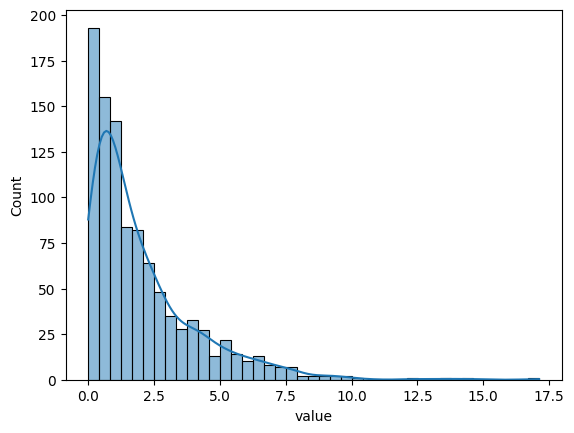

In [4]:
sns.histplot(data=df, x='value', kde=True)

In [16]:
from sklearn.preprocessing import PowerTransformer 
from sklearn.preprocessing import QuantileTransformer

pt_boxcox = PowerTransformer(method='box-cox', standardize=False)
pt_yeo_jhonson = PowerTransformer(method='yeo-johnson', standardize=False)
qt_normal = QuantileTransformer(output_distribution='normal')

# boxcox k liay data must be positive
df['Boxcox'] = pt_boxcox.fit_transform(df[['value']] + 1)
df['Yeo_Johnson'] = pt_yeo_jhonson.fit_transform(df[['value']])
df['Quantile'] = qt_normal.fit_transform(df[['value']]) 

In [17]:
df.head()

,value,Boxcox,Yeo_Johnson,Quantile
0,1.591749,0.787485,0.787485,0.162552
1,2.511862,0.980233,0.980233,0.587964
2,1.846446,0.849553,0.849553,0.286135
3,1.574402,0.782945,0.782945,0.157469
4,1.102097,0.639848,0.639848,-0.154930


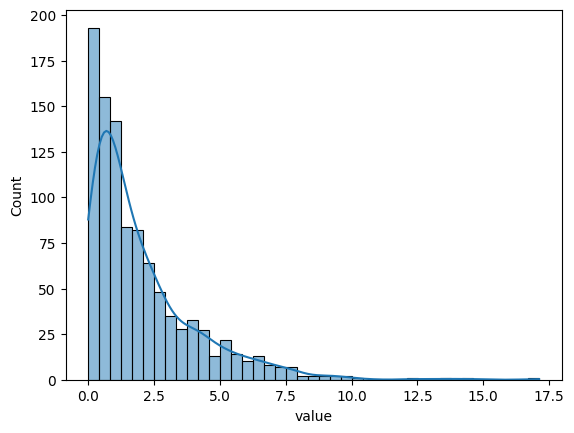

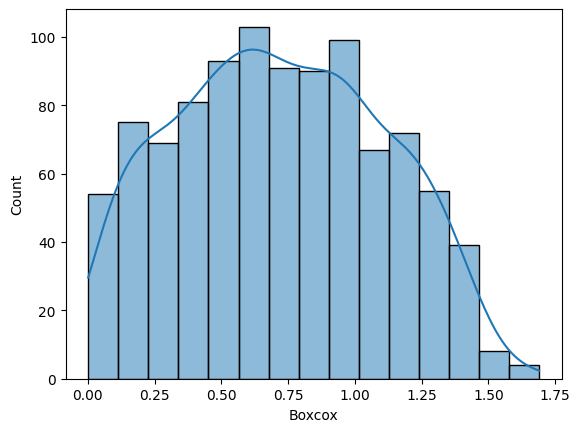

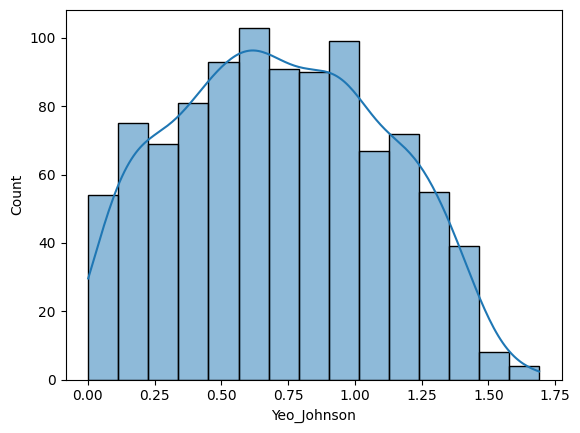

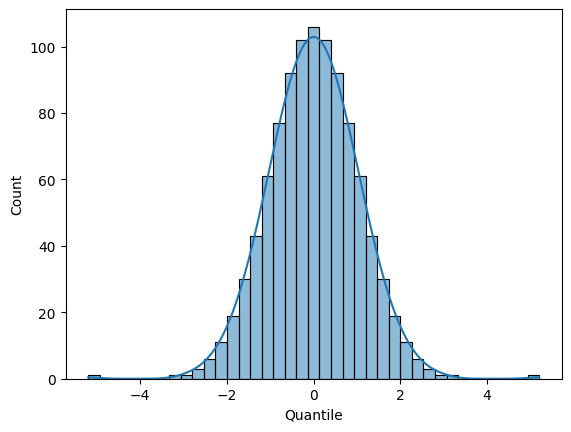

In [18]:
# create histograms for all columns using sns.hist anf kde=True use a for loop

for col in df.columns:
    sns.histplot(data=df, x=col, kde=True)
    plt.show()

----------

# Normalization


L2 Normalization:
 
rescales each sample (row) to have unit room. This type of normalization is often used when deling with text data.
the L2 norm is calculated as the square root of the sum of the squares vector values.

In [19]:
from sklearn.preprocessing import Normalizer
data =[[1,1,1], [1,1,0], [1,0,0]]
normalizer = Normalizer(norm='l2')
print(normalizer.fit_transform(data))

[[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]


L1 Normalization:

Also rescale each sample (row) but with a diffrent approach, ensuring the sum of the absolute values is 1 in each row. The L1 norm is calculated as the sum of the absolute vector values.

In [20]:
from sklearn.preprocessing import Normalizer
data =[[1,1,1], [1,1,0], [1,0,0]]
normalizer = Normalizer(norm='l1')
print(normalizer.fit_transform(data))

[[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


1. z-score normalization
   1.  standard scaler
2. min-max normalization
   1.  min-max scaler

# log Transformation

In [21]:
import pandas as pd
import numpy as np

# example dataset with skewed values 
df = {"Values":[1,5,10,20,50,100,200,500,1000,2000,5000,10000,20000,50000,100000]}
df = pd.DataFrame(df)
df.head()

,Values
0,1
1,5
2,10
3,20
4,50


In [27]:
df['log_values'] = np.log(df['Values'])
df.head

<bound method NDFrame.head of     Values  log_values
0        1    0.000000
1        5    1.609438
2       10    2.302585
3       20    2.995732
4       50    3.912023
5      100    4.605170
6      200    5.298317
7      500    6.214608
8     1000    6.907755
9     2000    7.600902
10    5000    8.517193
11   10000    9.210340
12   20000    9.903488
13   50000   10.819778
14  100000   11.512925>

<Axes: xlabel='Values', ylabel='Count'>

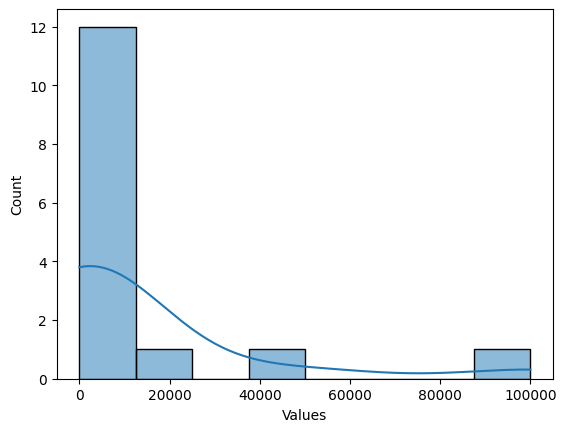

In [26]:
sns.histplot(data=df, x='Values', kde=True)

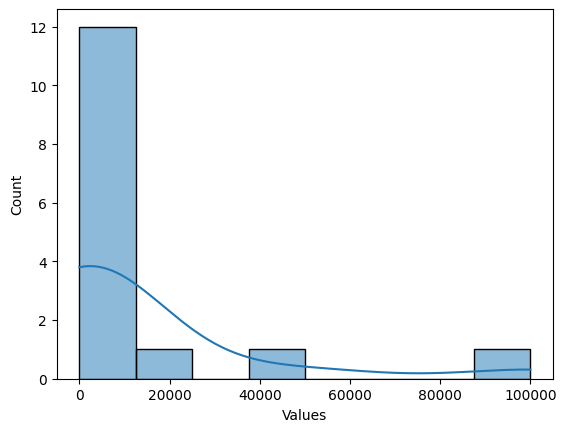

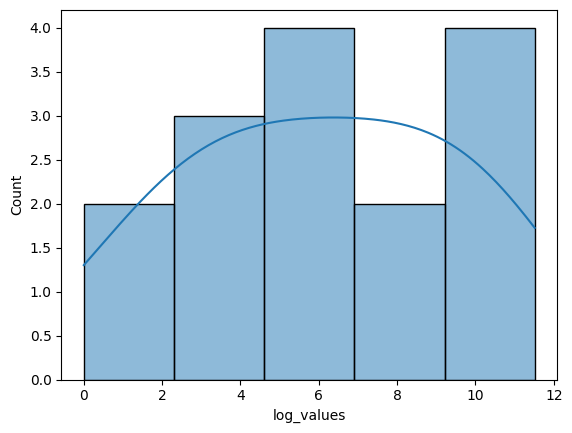

In [28]:
for col in df.columns:
    sns.histplot(data=df, x=col, kde=True)
    plt.show()